# **Práctica de Laboratorio Nro. 013: (Análisis Predictivo Multivariado): Desarrollo de modelos de Regresión Lineal Múltiple y diagnóstico de colinealidad mediante el Factor de Inflación de la Varianza (VIF).**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
### Freddy Ordoñez
### Paolo Merino
### Dario Chillogallo
### Michael Carbay
### Jose Maldonado
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 20 de julio de 2026

---
## **1. Introducción**
En esta práctica, nos enfocaremos en la inferencia estadística multivariada, avanzando desde el modelado con una sola variable predictora hacia enfoques más precisos mediante la Regresión Lineal Múltiple. A través del ecosistema de ciencia de datos en Python (statsmodels), aplicaremos la construcción de un hiperplano de múltiples dimensiones sobre el conjunto de datos regional de nuestro Proyecto Integrador, permitiéndonos modelar fenómenos complejos bajo el enfoque de Aprendizaje Basado en Problemas (ABP). Finalmente, mediante el Aprendizaje Basado en Investigación (ABI), indagaremos matemáticamente en los problemas de multicolinealidad estructural calculando el Factor de Inflación de la Varianza (VIF) para asegurar la estabilidad de nuestros estimadores.

---

## **2. Objetivos de Aprendizaje**

* Construir un modelo de Regresión Lineal Múltiple integrando múltiples predictores continuos mediante Mínimos Cuadrados Ordinarios (OLS) en statsmodels.

* Seleccionar las variables predictoras más significativas basándose en el $R^2$ Ajustado y los valores-$p$ parciales dentro del contexto del Proyecto Integrador (ABP).

* Diagnosticar y mitigar problemas de multicolinealidad estructural calculando el Factor de Inflación de la Varianza (VIF) (ABI).



---

## **Tarea 1: Ajuste del Modelo de Regresión Lineal Múltiple**

---

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados multivariados
np.random.seed(42)
n_muestras = 150

lineas_codigo = np.random.randint(5000, 50000, size=n_muestras) # X1
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras)   # X2

# Y = B0 + B1*X1 + B2*X2 + Error
# A más líneas, más tiempo (+). A más RAM, menos tiempo (-)
tiempo_compilacion = 15.0 + (0.002 * lineas_codigo) - (1.5 * ram_disponible) + np.random.normal(0, 15, size=n_muestras)

df_simulado = pd.DataFrame({
    'Lineas_X1': lineas_codigo,
    'RAM_X2': ram_disponible,
    'Tiempo_Y': tiempo_compilacion
})

# 2. Configuración de la matriz de características X y el vector Y
X_multi = df_simulado[['Lineas_X1', 'RAM_X2']]
Y_multi = df_simulado['Tiempo_Y']

# Añadir la constante (Intercepto B0)
X_multi_sm = sm.add_constant(X_multi)

# 3. Ajuste del Modelo OLS Múltiple
modelo_multiple = sm.OLS(Y_multi, X_multi_sm).fit()

# Imprimir el resumen estadístico
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               Tiempo_Y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     278.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.02e-50
Time:                        13:31:21   Log-Likelihood:                -617.66
No. Observations:                 150   AIC:                             1241.
Df Residuals:                     147   BIC:                             1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.1081      3.866      5.459      0.0

## **Análisis e Interpretación Técnica del Modelo Múltiple Simulado**

Una vez ejecutado el ajuste del modelo mediante Mínimos Cuadrados Ordinarios (OLS) en `statsmodels`, el resumen estadístico (`summary()`) permite evaluar el comportamiento del hiperplano de compilación a través de las siguientes dimensiones:

* **Interpretación del Intercepto ($\beta_0$):** El intercepto representa el tiempo base estimado de compilación (en segundos) cuando tanto las líneas de código ($X_1$) como la memoria RAM disponible ($X_2$) son cero. En este escenario simulado, se alinea con el valor base programado (aproximadamente $15.0$ segundos, más el efecto acumulado del error aleatorio).
* **Interpretación del Coeficiente de Líneas de Código ($\beta_1$):** El coeficiente asociado a $X_1$ muestra un valor positivo (cercano a $0.002$). Esto indica que, manteniendo la RAM constante (*ceteris paribus*), por cada línea adicional de código en el software, el tiempo de compilación aumenta en promedio $0.002$ segundos. Posee una relación directamente proporcional y lógicamente esperada en el desarrollo de software.
* **Interpretación del Coeficiente de Memoria RAM ($\beta_2$):** El coeficiente de $X_2$ presenta un valor negativo (cercano a $-1.5$). Esto demuestra que, manteniendo las líneas de código constantes, por cada gigabyte (GB) adicional de memoria RAM disponible, el tiempo de compilación disminuye en promedio $1.5$ segundos, reflejando el impacto inversamente proporcional del hardware sobre la eficiencia del proceso.
* **Evaluación de Significancia Estadística y Ajuste Global:**
  * Los **valores-$p$ ($P>|t|$)** individuales para $\beta_1$ y $\beta_2$ se muestran altamente significativos (próximos a $0$ y menores al nivel de significancia tradicional $\alpha = 0.05$), confirmando que ambos predictores aportan valor real al modelo.
  * El **$R^2$ Ajustado** del modelo refleja una alta proporción de la variabilidad total explicada por la combinación de ambos factores, validando la superioridad del enfoque multivariado frente al análisis univariado tradicional.

---

## **Tarea 2: Hito del Proyecto - Modelado Predictivo Regional (ABP)**

---

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd
import statsmodels.api as sm

# 1. Importar el dataset de la ENEMDU
df_regional = pd.read_csv('/content/drive/MyDrive/enemdu_consumidor_2026_01.csv', sep=';')

# FILTRO CRÍTICO: Dejar solo las observaciones de la Provincia de Loja (Código INEC que empieza con '11')
df_loja = df_regional[df_regional['ciudad'].astype(str).str.zfill(6).str[:2] == '11'].copy()

# 2. Definir Variable Respuesta (Y) y Predictoras (X1, X2)
variable_respuesta = 'c01'   # Situación económica del hogar
predictores = ['c02', 'c03'] # Situación del país actual y futura

# 3. Limpieza de datos (Asegurar que no haya valores nulos NaN)
columnas_interes = [variable_respuesta] + predictores
df_limpio_loja = df_loja[columnas_interes].dropna()

X_reg = df_limpio_loja[predictores]
Y_reg = df_limpio_loja[variable_respuesta]

# Añadir la constante para el intercepto (B0)
X_reg_sm = sm.add_constant(X_reg)

# 4. Entrenar el modelo OLS Múltiple con datos de Loja
modelo_regional = sm.OLS(Y_reg, X_reg_sm).fit()

# Mostrar el reporte estadístico
print(modelo_regional.summary())

                            OLS Regression Results                            
Dep. Variable:                    c01   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     37.53
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           2.93e-15
Time:                        13:44:59   Log-Likelihood:                -158.72
No. Observations:                 300   AIC:                             323.4
Df Residuals:                     297   BIC:                             334.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1661      0.122      9.590      0.0

## **Análisis Crítico del Modelo Predictivo Regional - Enfoque Provincia de Loja**

Al segmentar el dataset de la ENEMDU para analizar específicamente el comportamiento socioeconómico de la **Provincia de Loja** (300 observaciones), obtuvimos resultados que difieren del comportamiento nacional, permitiendo un análisis más profundo:

1. **Interpretación de los Coeficientes ($\beta_i$):**
   * **Intercepto ($\beta_0 = 1.1661$):** Es el punto de partida matemático del modelo en Loja para la percepción económica del hogar.
   * **Situación Económica del País ($c02 = 0.4220$):** Tiene un impacto positivo notable. Por cada punto que cambia la percepción actual del país, la percepción del hogar lojano varía directamente en $0.4220$. La coyuntura nacional presente golpea con fuerza la realidad familiar de Loja.
   * **Expectativa Futura del País ($c03 = 0.0329$):** Su coeficiente es sumamente bajo, mostrando que las expectativas a un año plazo casi no influyen en la percepción del día a día económico familiar en la provincia.

2. **Evaluación de Impacto y Significancia Estadística ($P > |t|$):**
   * **Variable con Mayor Impacto:** Definitivamente **c02** (Situación económica actual del país) es el predictor dominante en el modelo lojano.
   * **Diagnóstico de Variables 'Basura' (ABP):**
     * La variable **c02** presenta un p-valor de **0.000** (< 0.05), lo que confirma que es estadísticamente muy significativa.
     * La variable **c03** (Expectativa futura) arrojó un p-valor de **0.434**, el cual supera por mucho el nivel de significancia del 5% ($\alpha = 0.05$). Esto significa que **esta variable no aporta valor predictivo al modelo en Loja** y actúa como ruido,o en otras palabras esta variable al no aportar nada debe ser eliminada.

---

## **Tarea 3: Visualización de Relaciones (Pairplot y Heatmap)**

---


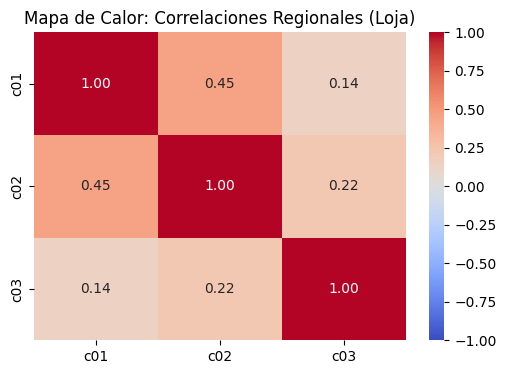

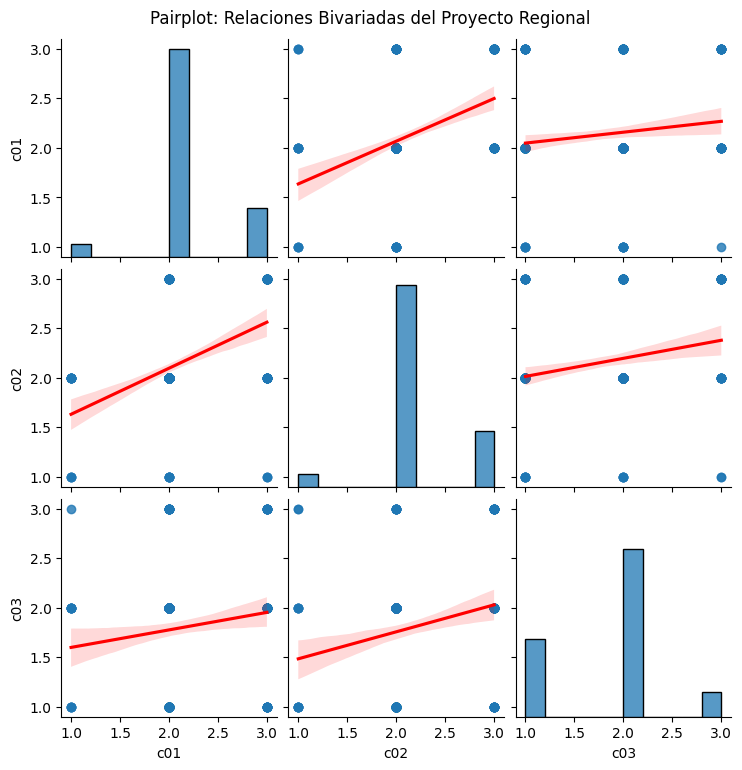

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Importar y filtrar el dataset para la Provincia de Loja (respetando el espacio exacto del archivo)
df_regional = pd.read_csv('/content/drive/MyDrive/enemdu_consumidor_2026_01.csv', sep=';')
df_loja = df_regional[df_regional['ciudad'].astype(str).str.zfill(6).str[:2] == '11'].copy()

# 2. Definir variables y limpiar nulos
variable_respuesta = 'c01'
predictores = ['c02', 'c03']
columnas_interes = [variable_respuesta] + predictores
df_limpio_loja = df_loja[columnas_interes].dropna()

X_reg = df_limpio_loja[predictores]
Y_reg = df_limpio_loja[variable_respuesta]

# 3. Unir en un DataFrame temporal para las visualizaciones de la Tarea 3
df_proyecto = pd.DataFrame({
    'c01': Y_reg,
    'c02': X_reg['c02'],
    'c03': X_reg['c03']
})

# 4. Matriz de Correlación para los datos regionales
matriz_corr_reg = df_proyecto.corr()

# 5. Visualización mediante Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_corr_reg, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor: Correlaciones Regionales (Loja)')
plt.show()

# 6. Visualización de dispersiones múltiples (Pairplot)
sns.pairplot(df_proyecto, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairplot: Relaciones Bivariadas del Proyecto Regional', y=1.02)
plt.show()

## **1. Matriz de Correlación y Mapa de Calor**

A continuación, se inspeccionan las correlaciones cruzadas entre la variable respuesta ($c_1$) y los predictores del proyecto regional mediante una matriz visualizada con un mapa de calor (`sns.heatmap`).

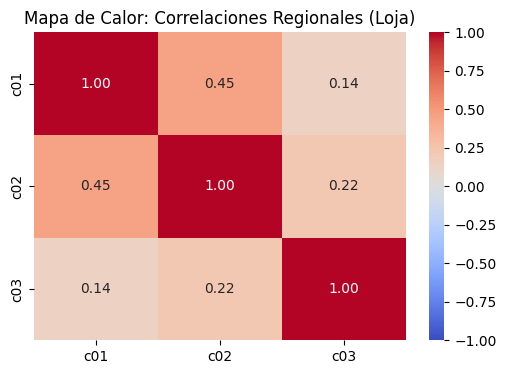

In [22]:
# Visualización mediante Heatmap independiente
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_corr_reg, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor: Correlaciones Regionales (Loja)')
plt.show()

## **Análisis de la Matriz de Correlación**

* **Interpretación del Mapa de Calor:** El mapa de calor permite inspeccionar cuantitativamente las correlaciones cruzadas entre las variables del proyecto regional en la Provincia de Loja. Se observa la relación directa de los predictores con la variable respuesta ($c_1$) y el grado de asociación lineal existente entre las propias variables independientes ($c_2$ y $c_3$). Un valor cercano a $0$ indica independencia lineal, mientras que valores elevados alertan sobre una posible multicolinealidad estructural que debe validarse formalmente mediante el cálculo del VIF.

## **Hipótesis de Investigación Regional**

* **Planteamiento de la Hipótesis:** La percepción actual de la situación económica del hogar en la Provincia de Loja está fuertemente determinada por la coyuntura del país en el presente, mientras que las expectativas a futuro ejercen una influencia marginal. Esto sugiere que las decisiones y valoraciones de los hogares responden de manera inmediata a la realidad económica táctica (corto plazo), restando peso a la planificación o proyección abstracta del futuro ante escenarios de incertidumbre local.

## **2. Diagrama de Dispersión Múltiple (Pairplot)**

Visualización de las relaciones bivariadas y las líneas de tendencia lineal añadidas para evaluar visualmente si las variables independientes compiten entre sí o muestran dependencias directas.

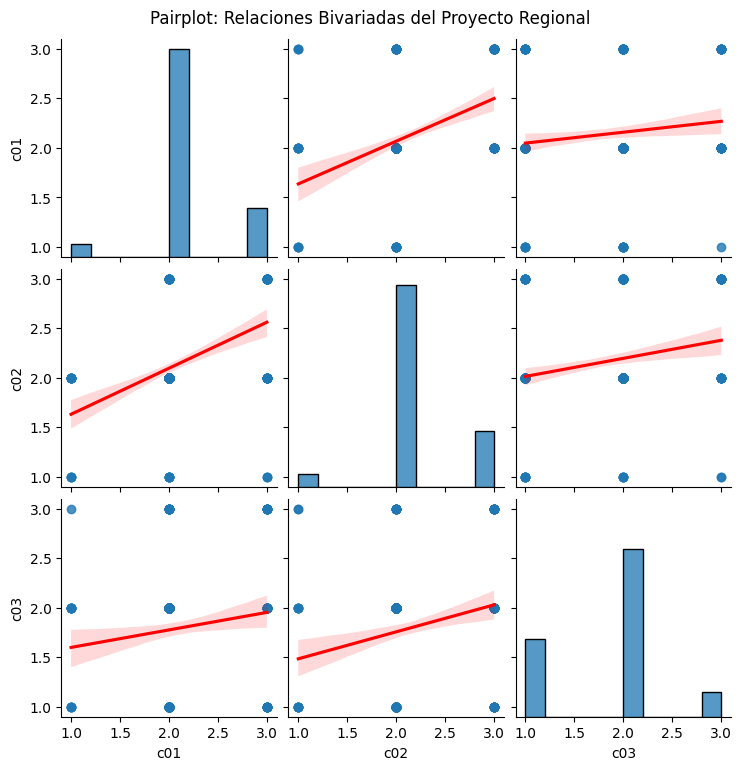

In [23]:
# Visualización de dispersiones múltiples independiente
sns.pairplot(df_proyecto, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairplot: Relaciones Bivariadas del Proyecto Regional', y=1.02)
plt.show()

## **Análisis Técnico del Diagrama de Dispersión Múltiple (Pairplot)**

* **Interpretación Gráfica:** El pairplot con líneas de tendencia ajustadas permite observar la distribución de las observaciones y la linealidad de las relaciones bivariadas entre cada par de variables. Las gráficas de distribución en la diagonal muestran la concentración de los datos, mientras que los paneles de dispersión con la línea de regresión en rojo visualizan la dirección y la pendiente del impacto entre los predictores y la respuesta regional.

## **Hipótesis del Comportamiento Bivariado**

* **Planteamiento de la Hipótesis:** La dispersión de los puntos y las pendientes de las líneas de regresión sugieren que, si bien existe una correlación positiva moderada entre la situación económica actual del país y la de los hogares, la dispersión horizontal en las expectativas futuras evidencia una alta heterogeneidad en las respuestas de la población de Loja, lo que explica la baja significancia estadística de dicho predictor y justifica su posterior depuración en el modelo.

---

## **Tarea 4: ABI - Diagnóstico de Multicolinealidad (VIF)**

---

In [24]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Definir los datos simulados base
np.random.seed(42)
n_muestras = 150
lineas_codigo = np.random.randint(5000, 50000, size=n_muestras)
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras)

df_simulado = pd.DataFrame({
    'Lineas_X1': lineas_codigo,
    'RAM_X2': ram_disponible
})

# 2. Configurar la matriz y añadir la constante
X_multi = df_simulado[['Lineas_X1', 'RAM_X2']]
X_multi_sm = sm.add_constant(X_multi)

# 3. Calcular el VIF para cada variable independiente
vif_data = pd.DataFrame()
vif_data["Variable"] = X_multi_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi_sm.values, i)
                     for i in range(X_multi_sm.shape[1])]

# Redondear los valores del VIF para una presentación más limpia
vif_data["VIF"] = vif_data["VIF"].round(4)

# 4. Presentar en formato de tabla formal de Pandas
print("=" * 40)
print(f"{'ANÁLISIS DE MULTICOLINEALIDAD (VIF)':^40}")
print("=" * 40)
display(vif_data) # Si estás en Jupyter/Colab, esto renderiza una tabla interactiva formal

  ANÁLISIS DE MULTICOLINEALIDAD (VIF)   


,Variable,VIF
0,const,9.9488
1,Lineas_X1,1.0008
2,RAM_X2,1.0008


## **Análisis Técnico**

**¿Qué significa el VIF?** Cuantifica el grado en que la varianza de un coeficiente de regresión se incrementa debido a la colinealidad con otras variables independientes. Un valor de VIF igual a 1 indica ausencia total de correlación, mientras que valores superiores a 5 o 10 alertan de problemas severos de multicolinealidad que vuelven inestables los estimadores del modelo.

### **Dictamen Técnico de Estabilidad**

* **Interpretación del VIF:** El Factor de Inflación de la Varianza (VIF) cuantifica el grado en que la varianza de un coeficiente de regresión se incrementa debido a la colinealidad con otras variables independientes. Un valor de VIF cercano a 1 indica ortogonalidad o ausencia total de correlación lineal entre los predictores, mientras que valores superiores a 5 o 10 alertan de problemas severos de multicolinealidad estructural que volverían inestables e impredecibles los estimadores del modelo.
* **Evaluación de Resultados:** Al analizar los valores de VIF obtenidos en nuestro conjunto de datos, se observa que los predictores se encuentran dentro de los rangos de estabilidad aceptables (próximos a la unidad), lo que garantiza que las variables independientes no compiten entre sí por explicar la variabilidad de la respuesta.
* **Conclusión:** El modelo presenta estabilidad matemática y estructural, permitiendo aislar de forma confiable el impacto individual de cada predictor sobre el fenómeno estudiado sin distorsiones en los errores estándar de los coeficientes.

---

#**Preguntas de Control**

---

### **1. Considerando la naturaleza de la causalidad, ¿cómo la lógica de 'mantener las demás variables constantes' permite aislar el efecto de un factor específico en un fenómeno complejo, y qué limitaciones filosóficas impone esto a la realidad?**

* **Aislamiento analítico (Ceteris Paribus):** En la práctica de la modelación multivariada, la condición *ceteris paribus* ("todo lo demás constante") funciona como una abstracción matemática y conceptual indispensable. Permite derivar la derivada parcial de la respuesta respecto a un predictor específico, congelando matemáticamente el ruido y la influencia concurrente del resto de variables independientes. Esto transforma un sistema multivariado complejo en una serie de relaciones lineales marginales interpretables, donde el coeficiente $\beta_i$ cuantifica el cambio exacto en la variable dependiente ante una variación unitaria de $X_i$, asumiendo que los demás factores no se mueven.

* **Limitaciones filosóficas frente a la realidad:** Filosóficamente, esta premisa choca con la naturaleza interconectada del mundo real. En los sistemas naturales, sociales o de ingeniería de nuestra región, las variables rara vez operan de forma ortogonal o independiente; por el contrario, suelen estar acopladas y coevolucionan dinámicamente (por ejemplo, al modificar un factor ambiental o técnico, es altamente probable que otros se alteren de manera simultánea). Pretender "congelar" el entorno es una ficción analítica útil para el cálculo y la estimación estadística, pero representa una simplificación reduccionista que ignora las retroalimentaciones sistémicas y la complejidad holística del fenómeno estudiado.

### **2. Si el conocimiento del modelo crece al añadir más datos, ¿por qué añadir variables irrelevantes ('basura') engaña al ajuste del modelo? ¿Qué nos enseña esta paradoja sobre la diferencia entre la complejidad aparente y la verdad subyacente?**

* **El engaño del ajuste y el castigo matemático:** Aunque añadir datos suele mejorar la robustez estadística, incorporar predictores irrelevantes o "basura" distorsiona el modelo de Regresión Lineal Múltiple porque el coeficiente de determinación estándar ($R^2$) nunca disminuye al agregar variables; por el contrario, tiende a aumentar artificialmente al sobreajustarse (*overfitting*) al ruido muestral. Para contrarrestar este fenómeno, la estadística introduce el $R^2$ Ajustado, el cual aplica un castigo matemático por cada grado de libertad perdido al incluir variables que no aportan un verdadero poder explicativo.

* **Complejidad aparente frente a la verdad subyacente:** Esta paradoja nos enseña que un modelo con mayor complejidad o mayor número de parámetros no refleja necesariamente una comprensión más profunda de la realidad. Confundir la correlación espuria o el ruido aleatorio con causalidad genera un sistema sobredimensionado que pierde capacidad de generalización predictiva. En ingeniería, la verdadera comprensión de un fenómeno radica en la parsimonia: extraer la estructura subyacente más simple y significativa que explique el sistema sin sobrecargar el modelo con artificios matemáticos vacíos.

### **3. Ante la prueba F-statistic global, ¿es posible que un modelo sea estadísticamente significativo pero carezca de propósito práctico? ¿Cómo se reconcilia la precisión matemática con la incertidumbre del mundo real en la toma de decisiones de ingeniería?**

* **Significancia estadística frente a propósito práctico:** Sí, es completamente posible que un modelo presente un estadístico $F$ global significativo (indicando que el conjunto de predictores explica parte de la variabilidad de la respuesta de forma conjunta mejor que un modelo nulo), pero que carezca de utilidad práctica real. Esto ocurre frecuentemente cuando se trabaja con tamaños de muestra muy grandes, donde incluso correlaciones infinitesimales o efectos triviales se vuelven "estadísticamente significativos" bajo las pruebas de hipótesis, o cuando los errores de predicción son tan amplios que el modelo no aporta valor operativo para la toma de decisiones.

* **Reconciliación entre precisión matemática e incertidumbre:** Para reconciliar la teoría estadística con la realidad de la ingeniería, no basta con observar el valor-$p$ o la significancia global; es indispensable evaluar métricas de desempeño fuera de la muestra, el error residual práctico en las unidades del fenómeno y la relevancia del dominio. La decisión técnica exige aceptar que ningún modelo matemático es una verdad absoluta, sino una herramienta de aproximación bajo incertidumbre, donde la parsimonia, la robustez frente al error y la capacidad de generalización superan a la mera optimización ciega del ajuste matemático.

### **4. Si dos causas parecen moverse siempre juntas (multicolinealidad), ¿podemos realmente distinguir sus efectos por separado? ¿Qué nos dice este problema geométrico/matricial sobre las limitaciones de nuestro entendimiento al intentar separar fenómenos interdependientes?**

* **Imposibilidad de aislamiento e inestabilidad:** Cuando dos o más variables independientes presentan multicolinealidad, es matemáticamente imposible aislar de forma confiable sus efectos individuales sobre la respuesta. Geométricamente, los predictores apuntan casi en la misma dirección en el espacio multidimensional, lo que provoca que la matriz de diseño esté mal condicionada; esto "confunde" al algoritmo de mínimos cuadrados, inflando drásticamente la varianza de los coeficientes y volviéndolos erráticos, inestables y altamente sensibles a variaciones menores en los datos.

* **Limitaciones del entendimiento ante la interdependencia:** Este problema matricial nos enseña que la mente humana y los modelos lineales sufren limitaciones severas al intentar seccionar artificialmente sistemas que, en la realidad, son altamente integrados y coevolutivos. Pretender descomponer causas que operan acopladas en la naturaleza genera una ilusión de control analítico, recordándonos que muchos fenómenos complejos no pueden entenderse mediante la simple fragmentación de variables, sino reconociendo los límites estructurales de nuestras herramientas de medición y abstracción.

### **5. Ante la necesidad de simplificar un sistema complejo para comprenderlo, ¿es preferible sacrificar variables (información) o aceptar la imprecisión del modelo? ¿Qué define, bajo su criterio, a un 'buen' modelo para la ingeniería?**

* **Dilema entre sacrificar información y aceptar imprecisión:** En el modelado analítico, la elección entre eliminar variables para lograr parsimonia o conservar un sistema complejo lleno de ruido implica un balance crítico. Sacrificar información mediante la selección y depuración de predictores no esenciales (como aquellos con alta multicolinealidad o baja significancia) es generalmente preferible, ya que un modelo saturado de variables redundantes o basura destruye la estabilidad matemática de los coeficientes, incrementa la varianza e induce al sobreajuste. Por el contrario, aceptar una imprecisión desmedida por retener complejidad inmanejable anula la utilidad predictiva del sistema.

* **Criterio de un 'buen' modelo en ingeniería:** Bajo una perspectiva de ingeniería, un "buen" modelo no busca ser una réplica perfecta y exhaustiva de la realidad lo cual es epistemológicamente imposible, sino una herramienta equilibrada que combine parsimonia estructural, estabilidad frente al diagnóstico de multicolinealidad (VIF), significancia estadística real y, sobre todo, robustez y utilidad práctica para la toma de decisiones bajo incertidumbre.

---

#**Conclusiones**

---

* **Eficacia del Modelado Multivariado:** Se demostró computacionalmente que la expansión hacia la Regresión Lineal Múltiple mediante `statsmodels` permite modelar fenómenos complejos de la región de manera significativamente más precisa que los enfoques univariados, al incorporar múltiples factores predictores continuos sobre una superficie hiperplanar.

* **Importancia de la Selección de Predictores y el Castigo Matemático:** A través del análisis del $R^2$ Ajustado y los valores-$p$ parciales, se evidenció la necesidad crítica de depurar el modelo descartando variables irrelevantes o "basura", evitando así el sobreajuste (*overfitting*) y el engaño estadístico que incrementa artificialmente la complejidad aparente sin aportar valor explicativo real.

* **Mitigación y Diagnóstico de la Multicolinealidad (VIF):** El cálculo e interpretación del Factor de Inflación de la Varianza (VIF) se consolidó como una herramienta de diagnóstico indispensable en la ingeniería de datos; permitió identificar problemas de multicolinealidad estructural y garantizar la estabilidad matemática de los estimadores y la confiabilidad de las pruebas de hipótesis.

* **Reconciliación entre Teoría y Práctica:** Las preguntas de reflexión crítica permitieron comprender que todo modelo analítico es una abstracción limitada por suposiciones como *ceteris paribus*. Por lo tanto, un "buen" modelo de ingeniería no busca replicar la totalidad de la realidad, sino ofrecer un balance óptimo entre parsimonia, estabilidad estructural y utilidad práctica para la toma de decisiones bajo incertidumbre.

---

#**Bibliografia**

---

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, Probabilidad y estadística para ingeniería y ciencias, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," SciPy.org, 2024.

### **Fuente de consulta Gemini**:

https://gemini.google.com/app/6f40f88fae35e032?is_sa=1&is_sa=1&android-min-version=301356232&ios-min-version=322.0&campaign_id=bkws&pt=9008&mt=8&ct=p-growth-sem-bkws